# Financial Econometrics I - Homework 1
#### **Authors:** Maxim Milde (`73267075`), Zahid Pashayev (`54520099`)
**Individual contributions**:

**AI tool usage**:

---

In [1]:
setwd("/Users/zp/Desktop/Financial_Econ")

In [2]:
library("ggplot2") #plotting
library("moments") #for skew and kurtosis
library("stabledist") #for stable dist curve
library("fBasics") #for stable dist param estimation


Attaching package: ‘fBasics’


The following objects are masked from ‘package:moments’:

    kurtosis, skewness




## Problem 1 Part 1

### 1.  Setup and Data Cleaning

In [3]:
base_path <- getwd()
print(base_path)

all_files <- c(list.files(file.path(base_path, "73267075"), full.names=TRUE),
               list.files(file.path(base_path, "54520099"), full.names=TRUE)
)

price_list_raw <- lapply(all_files, read.csv)
names(price_list_raw) <- tools::file_path_sans_ext(basename(all_files)) #get the names of all stocks
names(price_list_raw)

head(price_list_raw[["BIO"]]) #check the structure of the data

[1] "/Users/zp/Desktop/Financial_Econ"


[1] "BIO"  "CPT"  "ELV"  "FE"   "HCA"  "MKTX" "STT"  "XOM"  "BSX"  "CAH" 
[11] "CVX"  "GM"   "ICE"  "MCHP" "MDLZ" "PHM"  "QRVO" "WHR"

,Date,Open,High,Low,Close,Volume,Dividends,Stock.Splits
,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>
1,2019-01-02,229.73,231.23,226.73,228.08,165800,0,0
2,2019-01-03,228.18,231.26,223.89,224.3,180200,0,0
3,2019-01-04,224.50,228.34,224.11,226.28,446800,0,0
4,2019-01-07,227.52,234.82,227.26,233.67,354300,0,0
5,2019-01-08,235.00,236.91,232.48,235.53,235800,0,0
6,2019-01-09,236.61,241.40,236.61,237.37,266100,0,0


We do not observe duplicated tickers from both files, so no need for special naming. 

In [4]:

sapply(price_list_raw, colnames) #check if column names are same format
colnames(price_list_raw[["PHM"]])[2] <- "Close" #correct PHM Close column


$BIO
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$CPT
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$ELV
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$FE
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$HCA
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$MKTX
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$STT
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$XOM
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$BSX
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$CAH
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$CVX
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$GM
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$ICE
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$MCHP
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$MDLZ
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$PHM
[1] "Date"   "Klose"  "Open"   "High"   "Low"    "Volume"

$QRVO
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

$WHR
[1] "Date"         "Open"         "High"         "Low"          "Close"       
[6] "Volume"       "Dividends"    "Stock.Splits"

`PHM` contains "Klose" instead of "Close"

In [5]:
price_list <- lapply(price_list_raw, function(df) df[, c("Date", "Close")])
sapply(price_list, colnames)

BIO,CPT,ELV,FE,HCA,MKTX,STT,XOM,BSX,CAH,CVX,GM,ICE,MCHP,MDLZ,PHM,QRVO,WHR
Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date,Date
Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close,Close


We now have only the columns we are interested in.

In [6]:
str(price_list[["BIO"]]) #check for disparities
str(price_list[["CAH"]]) #need to reformat the column types

price_list <- lapply(price_list, function(df) {
    df$Date <- as.Date(df$Date)
    df$Close <- as.numeric(df$Close)
    return(df)
})

sapply(price_list, function(df) sum(is.na(df$Close)))

'data.frame':	1759 obs. of  2 variables:
 $ Date : chr  "2019-01-02" "2019-01-03" "2019-01-04" "2019-01-07" ...
 $ Close: chr  "228.08" "224.3" "226.28" "233.67" ...
'data.frame':	1758 obs. of  2 variables:
 $ Date : chr  "2019-01-02" "2019-01-03" "2019-01-04" "2019-01-07" ...
 $ Close: num  36.9 36.2 36.8 37.5 38.1 ...


Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”


BIO  CPT  ELV   FE  HCA MKTX  STT  XOM  BSX  CAH  CVX   GM  ICE MCHP MDLZ  PHM 
   1    0    1    0    0    0    0    1    0    0    0    0    1    1    1    0 
QRVO  WHR 
   0    0

Need to drop NAs, so returns can be calculated properly.

In [7]:
price_list <- lapply(price_list, function(df) na.omit(df)) #remove NAs
sapply(price_list, function(df) sum(is.na(df$Close)))

sapply(price_list, function(df) sum(duplicated(df$Date))) #check for date duplicates

BIO  CPT  ELV   FE  HCA MKTX  STT  XOM  BSX  CAH  CVX   GM  ICE MCHP MDLZ  PHM 
   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
QRVO  WHR 
   0    0

BIO  CPT  ELV   FE  HCA MKTX  STT  XOM  BSX  CAH  CVX   GM  ICE MCHP MDLZ  PHM 
   0    0    0    0    0    0    0    0    0    0    0    0    0    0    0    0 
QRVO  WHR 
   0    0

### 2. Returns

In [8]:
rets_list <- lapply(price_list, function(df){
    data.frame(
        Date = df$Date[-1], #remove 1st date as we don't have return for it
        rets = diff(log(df$Close)),
        rets_simple = diff(df$Close)/df$Close[-nrow(df)]
    )
})

head(rets_list[["BIO"]])

,Date,rets,rets_simple
,<date>,<dbl>,<dbl>
1,2019-01-03,-0.016712003,-0.016573132
2,2019-01-04,0.008788729,0.008827463
3,2019-01-07,0.032136693,0.032658653
4,2019-01-08,0.007928430,0.007959944
5,2019-01-09,0.007781811,0.007812168
6,2019-01-10,0.014637264,0.014744913


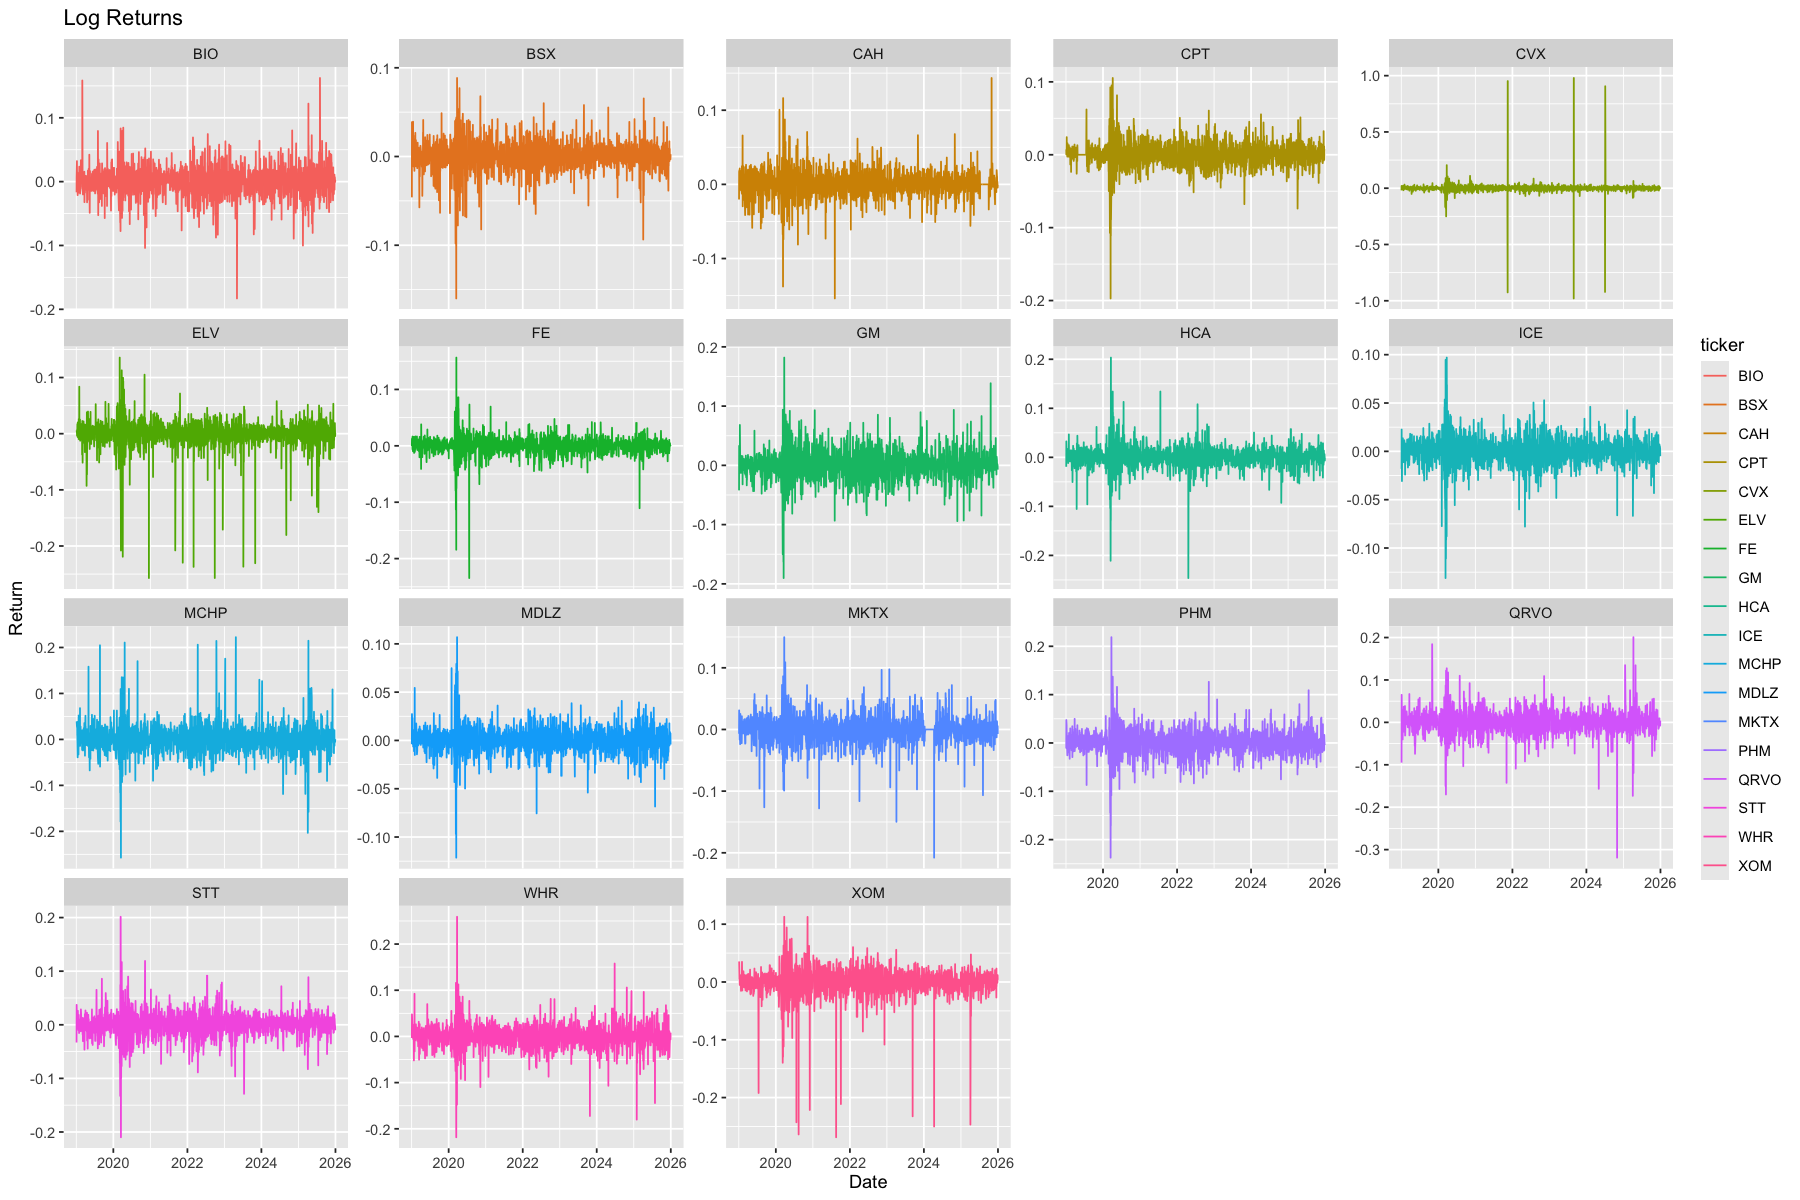

In [9]:
#combine the returns into a long data frame for ggplot2
rets_long <- do.call(rbind, lapply(names(rets_list), function(name) {
    data.frame(
        Date=rets_list[[name]]$Date,
        rets=rets_list[[name]]$rets,
        ticker=name
    )
}))

options(repr.plot.width=15, repr.plot.height=10)
ggplot(rets_long, aes(x=Date, y=rets, color=ticker)) +
    geom_line() + 
    facet_wrap(~ticker, scales="free_y") +
    labs(title="Log Returns", x="Date", y="Return")

From the plots, we observe that it is quite common to have daily retuns of &plusmn; 10-20%, even 30%. 

Nevertheless, `CVX` particularly stands out as it has several spikes of &plusmn; ~100% magnitude - likely a data issue.

### 3. Summary Statistics

In [ ]:
desc_stat <- do.call(rbind, lapply(names(rets_list), function(name){
    r <- rets_list[[name]]$rets
    data.frame(
        ticker = name,
        mean = mean(r),
        sd = sd(r),
        min = min(r),
        max = max(r),
        skew = skewness(r),
        kurt = kurtosis(r)
    )
}))

format(desc_stat, digits=2)

As expected, `CVX` is a clear outlier, with kurtosis of ~228 and extreme min (-98%) and max (98%) values.

Other larger leptokurtic tickers include: `FE`, `ELV` and `XOM`, all with kurtosis above 30.
They are also the most largely skewed - likely affected by real negative events. However, `CVX` does not have a skew of high magnitude (minimal), which suggests that it is most likely a data issue.

There do not appear to be other exteme or unusual statistics.

,Date,rets,rets_simple
,<date>,<dbl>,<dbl>
724,2021-11-15,-0.9256495,-0.6037261
725,2021-11-16,0.9520014,1.5908898
1170,2023-08-29,-0.9795360,-0.6245147
1171,2023-08-30,0.9793483,1.6627205
1381,2024-07-03,-0.9216510,-0.6021384
1382,2024-07-05,0.9059602,1.4743066


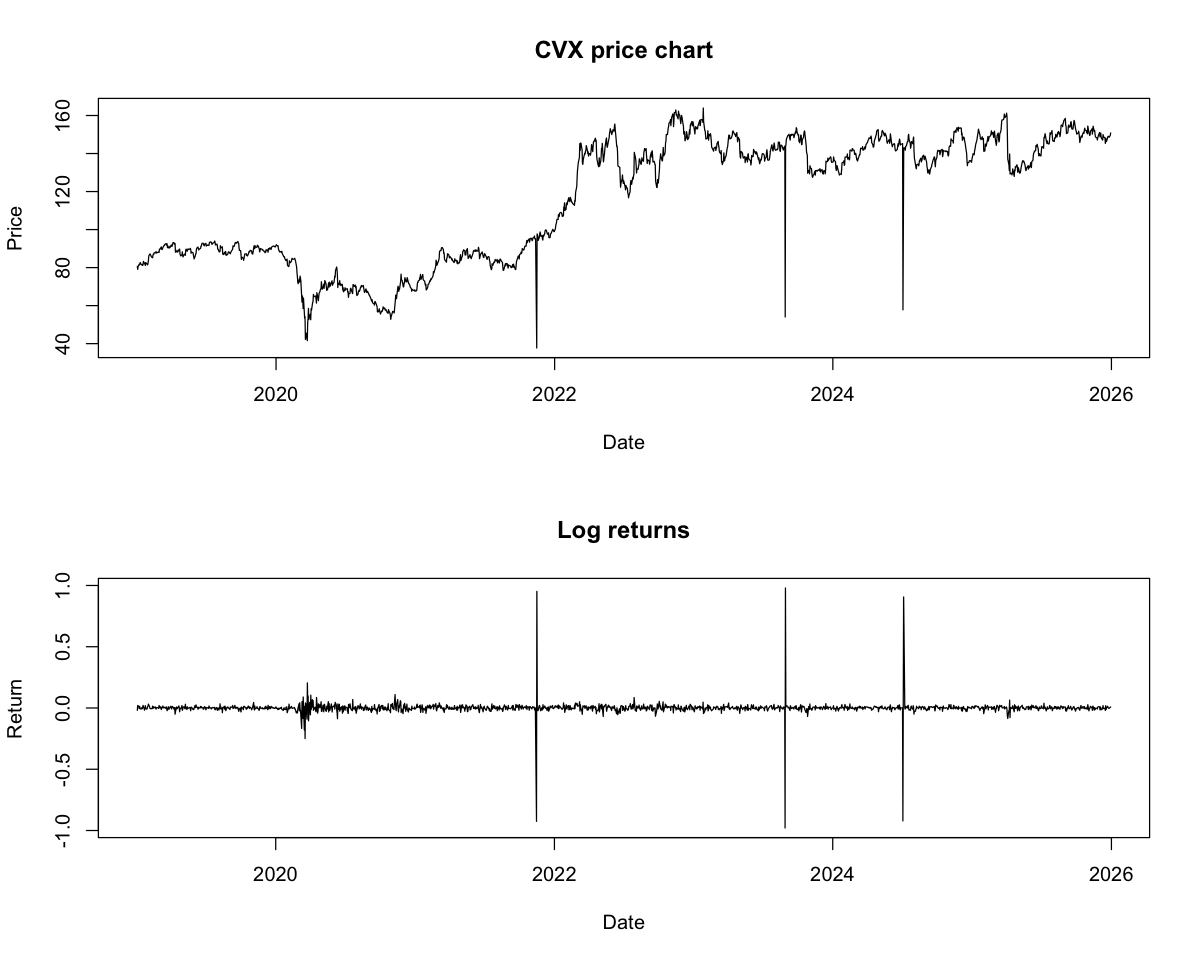

In [10]:
options(repr.plot.width=10, repr.plot.height=8)
par(mfrow=c(2,1))

plot(price_list[["CVX"]]$Date, price_list[["CVX"]]$Close, 
    type='l', main="CVX price chart", xlab="Date", ylab="Price"
)

plot(rets_list[["CVX"]]$Date, rets_list[["CVX"]]$rets, 
    type='l', main="Log returns", xlab="Date", ylab="Return"
)

rets_list[["CVX"]][abs(rets_list[["CVX"]]$rets) > 0.5, ] #to get the exact dates of the outlier dates

Upon further inspection, it can be seen that on 3 occasions, the stock price drops drastically and then recovers the next day. One possibility of such price change would be innapropriate stock split data handling, however `CVX` last stock split was in 2004. As such, it seems that the issue is simply wrong data entry.

To ensure appropriate return modelling and comparison, we trim those observations. Winsorizing would be innapropriate as making an estimate of the returns on those days would affect the return distribution. Given that we have established that those observations are not true outliers, but data handling errors, we find it most appropriate to simply remove them. Trimming at the 50% absolute value of returns is appropriate as no true observations exceed this amount, only the wrong entries.

In [11]:
rets_list[["CVX"]] <- rets_list[["CVX"]][abs(rets_list[["CVX"]]$rets) < 0.5, ] #keep only ret < 50% in magnitude

Mean: 0.0003522917 
SD: 0.02043079 
Min: -0.2500552 
Max: 0.2049111 
Skewness: -1.132913 
Kurtosis: 26.62659

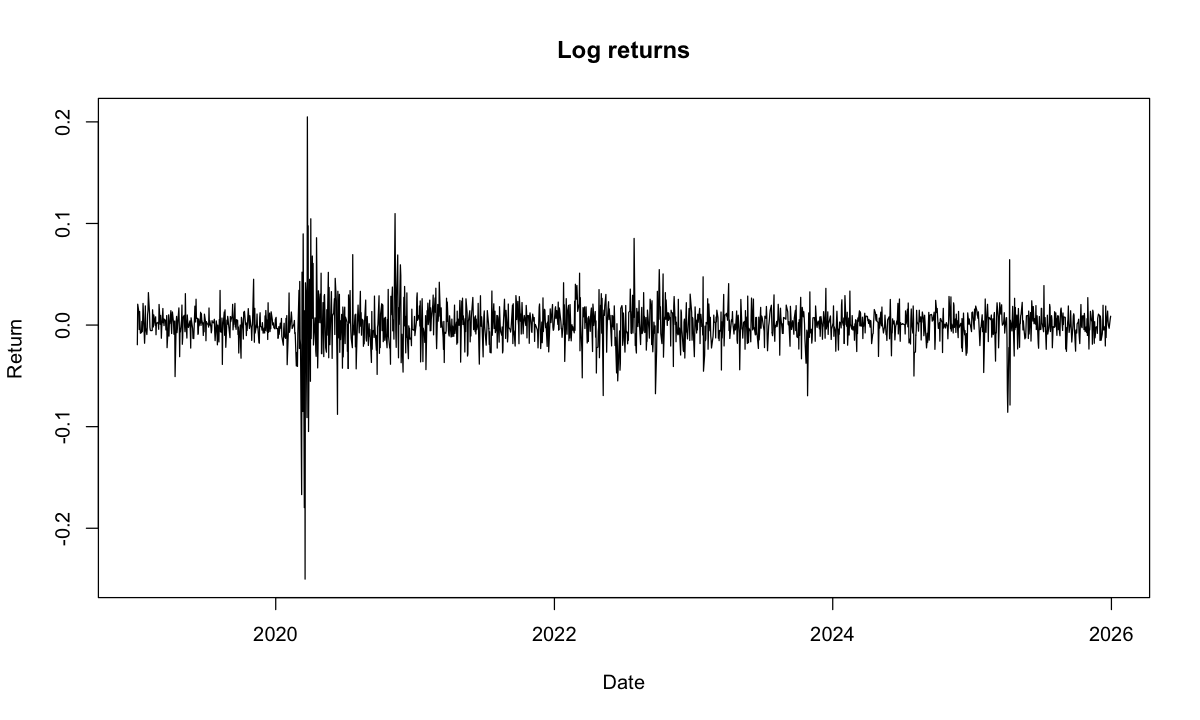

In [12]:
options(repr.plot.width=10, repr.plot.height=6)
plot(rets_list[["CVX"]]$Date, rets_list[["CVX"]]$rets, 
    type='l', main="Log returns", xlab="Date", ylab="Return"
)

CVX <- rets_list[["CVX"]]$rets
cat("Mean:", mean(CVX), 
    "\nSD:", sd(CVX), 
    "\nMin:", min(CVX), 
    "\nMax:", max(CVX), 
    "\nSkewness:", skewness(CVX), 
    "\nKurtosis:", kurtosis(CVX)
)

The issue is fixed.

Still, kurtosis is close to 30 and skewness has a magnitude above 1. 

Nevertheless, we will further investigate the ticker with highest kurtosis out of the sample, as the one to be the furthest away from a normal distribution. This is because kurtosis signals fat tails - extreme events happen more frequently, meanwhile negative skew (what we see in most stocks) simply suggests that most of the density is in a negative area.

### 4. Normality

We identify `FE` to be the ticker with highest lepptokurtic properties (45.2).

agg_record_445146130 
                   2

       alpha         beta        gamma        delta 
 1.559000000 -0.219000000  0.007255068  0.001612289 


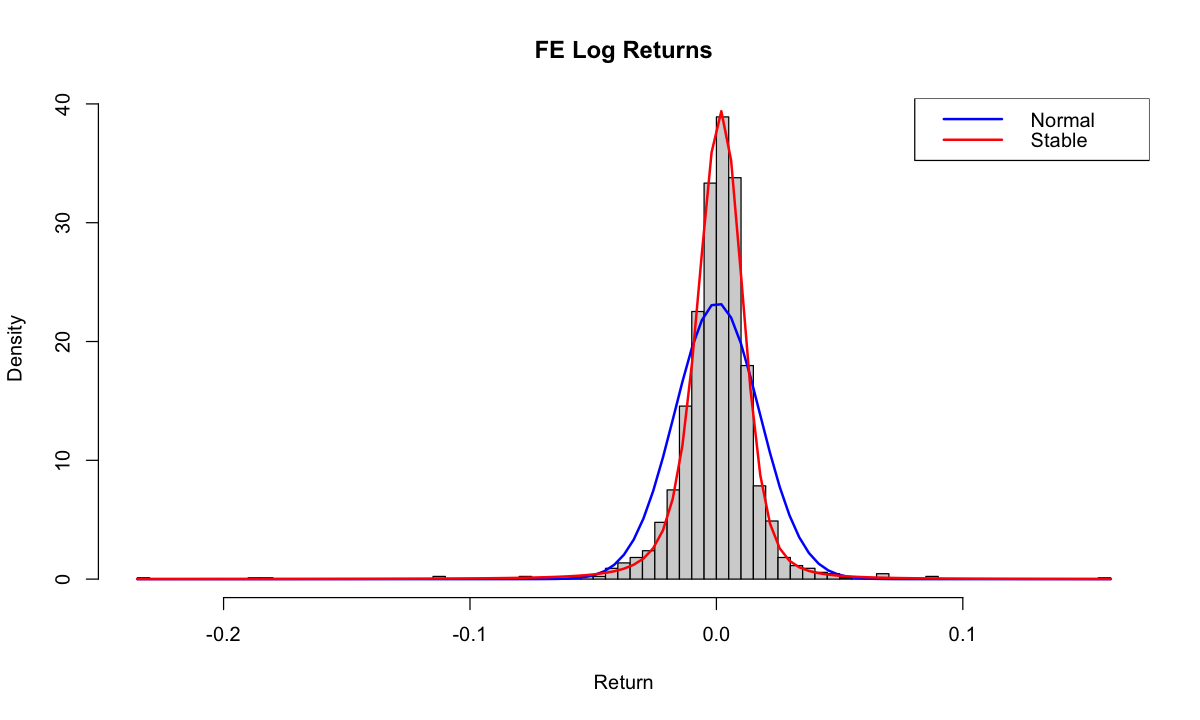

In [13]:
FE <- rets_list[["FE"]]$rets #plotting log returns - more likely to be normal than simple returns

pdf(NULL) #because stableFit produces an unnecessary graph
stable_param <- stableFit(FE, type="q") #fit the stable distrib (get the parameters)
dev.off()

print(stable_param@fit$estimate)
hist(FE, breaks=100, freq=FALSE, main="FE Log Returns", xlab="Return")

curve(dnorm(x, mean=mean(FE), sd=sd(FE)), add=TRUE, col="blue", lwd=2) #normal distrib 

curve(dstable(x,alpha=stable_param@fit$estimate[1], #stable distrib
                beta=stable_param@fit$estimate[2],
                gamma=stable_param@fit$estimate[3],
                delta=stable_param@fit$estimate[4]),
    add=TRUE, col="red", lwd=2
)

legend("topright", legend=c("Normal", "Stable"), col=c("blue", "red"), lwd=2)

- Alpha: tail heaviness 
- Beta: skewness
- Gamma: scale (similar to sd)
- Delta: location (similar to mean)

The stable distribution parameters indicate significant tail risk, slight negative skewness and a location of near zero.

It is evident that using a normal distribution to model `FE`'s stock returns would be greatly inappropriate. The probability of an extreme negative shock to the stock price is much larger than the normal distribution predicts. This can have large implications on portfolio risk management. If the normal distribution is used to model a portfolio return distribution with large kurtosis (and negative skewness), risk measures such as Value at Risk and Expected Shortfall could be largely understated. Failing to appropriately account for tail risk could have devastating consequences. A clearer image of the left tail can be seen below.

The fitted stable distribution has $\alpha$ < 2, which implies a theoretically infinate variance. As such, in practice it comes at a cost. Risk measurement requires some sort of finate second moments.


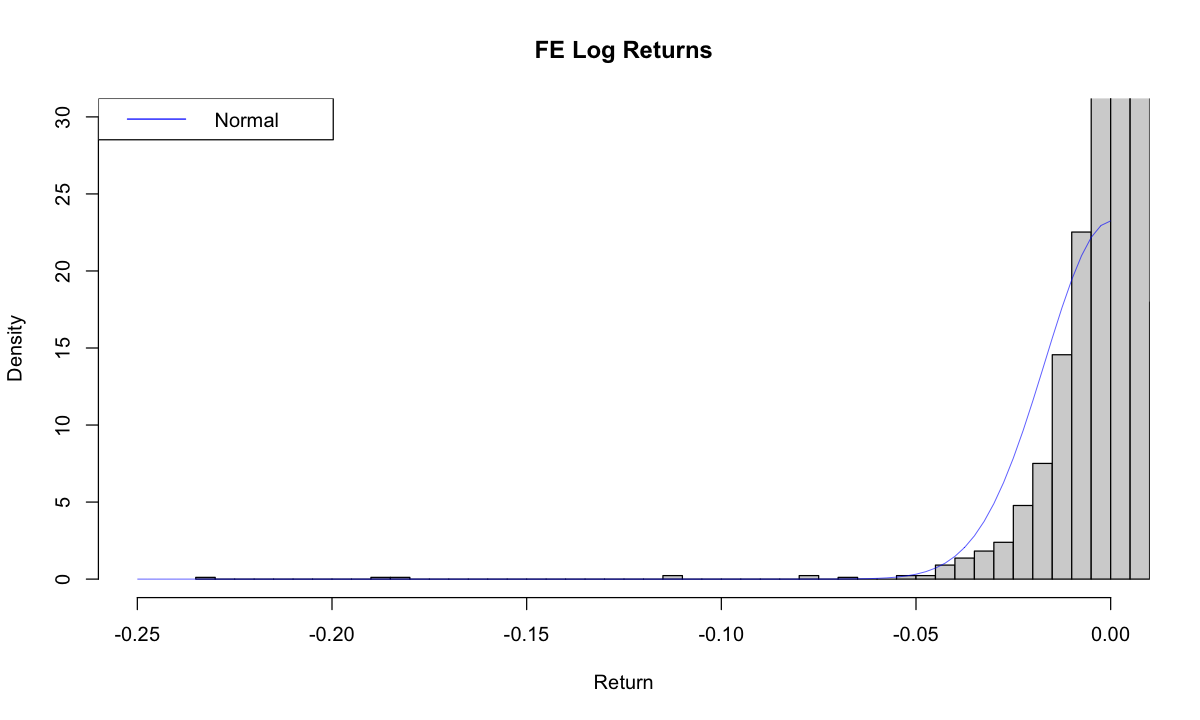

In [14]:
hist(FE, breaks=100, freq=FALSE, main="FE Log Returns", xlab="Return", xlim=c(-0.25, -0), ylim=c(0, 30))
curve(dnorm(x, mean=mean(FE), sd=sd(FE)), add=TRUE, col="blue", lwd=0.5)
legend("topleft", legend="Normal", col="blue", lwd=1)

## Part 2

### 1.

In [15]:
#Checking dates & observations for each stock before combining them 
date_summary <- data.frame(
    ticker = names(rets_list),
    observations = sapply(rets_list, nrow),
    start_date = as.Date(sapply(rets_list, function(df) min(df$Date))),
    end_date = as.Date(sapply(rets_list, function(df) max(df$Date)))
)
                          
date_summary

,ticker,observations,start_date,end_date
,<chr>,<int>,<date>,<date>
BIO,BIO,1757,2019-01-03,2025-12-30
CPT,CPT,1758,2019-01-03,2025-12-30
ELV,ELV,1757,2019-01-04,2025-12-30
FE,FE,1758,2019-01-03,2025-12-30
HCA,HCA,1758,2019-01-03,2025-12-30
MKTX,MKTX,1758,2019-01-03,2025-12-30
STT,STT,1758,2019-01-03,2025-12-30
XOM,XOM,1756,2019-01-04,2025-12-30
BSX,BSX,1756,2019-01-03,2025-12-30


We can see that all the series cover approximately same time periods (Jan 2019 - Dec 2025) with roughly similar observations. The only noticeable difference comes from CVX outlier. The small differences (a few rows) come from the CVX outlier trimming in Part 1 and minor date mismatches. No series has excessive missing values — the largest gap is only a handful of days. If a series had, say, 20–30% fewer observations than the rest, we would drop it before merging to avoid unnecessarily shrinking the common date set for all other tickers.

In [16]:

# Only dates shared by all tickers are kept
stock_list <- lapply(names(rets_list), function(ticker_name) {
  stock_data <- rets_list[[ticker_name]][, c("Date", "rets")]
  colnames(stock_data)[2] <- ticker_name
  stock_data}
)

aligned_rets <- Reduce(function(left, right) merge(left, right, by = "Date"), stock_list)
aligned_rets <- aligned_rets[order(aligned_rets$Date), ]

#Checking the overall state of combined dataset
portfolio_summary <- data.frame(
  trading_days = nrow(aligned_rets),
  number_of_series = ncol(aligned_rets) - 1,
  first_date = as.character(min(aligned_rets$Date)),
  last_date = as.character(max(aligned_rets$Date))
)
                       
portfolio_summary

trading_days,number_of_series,first_date,last_date
<int>,<dbl>,<chr>,<chr>
1733,18,2019-01-04,2025-12-30


In [17]:
#see how many rows each ticker lost after aligning dates
obs_lost <- sapply(names(rets_list),function(name) {
    nrow(rets_list[[name]]) - nrow(aligned_rets)}
                  )

sort(obs_lost, decreasing = TRUE)

CPT   FE  HCA MKTX  STT QRVO  BIO  ELV  CAH  ICE MCHP  PHM  XOM  BSX   GM MDLZ 
  25   25   25   25   25   25   24   24   24   24   24   24   23   23   23   23 
 WHR  CVX 
  21   16

In [18]:
tickers <- setdiff(colnames(aligned_rets), "Date")
aligned_rets$mean_ret <- rowMeans(aligned_rets[, tickers])

#Quick look at the distribution
mean_stats <- data.frame(
    mean = mean(aligned_rets$mean_ret),
    sd = sd(aligned_rets$mean_ret),
    min = min(aligned_rets$mean_ret),
    q1 = quantile(aligned_rets$mean_ret, 0.25),
    median = median(aligned_rets$mean_ret),
    q3 = quantile(aligned_rets$mean_ret, 0.75),
    max = max(aligned_rets$mean_ret),
    skewness = skewness(aligned_rets$mean_ret),
    kurtosis = kurtosis(aligned_rets$mean_ret)
)

mean_stats

,mean,sd,min,q1,median,q3,max,skewness,kurtosis
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
25%,0.0002774959,0.01367917,-0.1633216,-0.005452728,0.0005973788,0.006866844,0.1237977,-1.15847,23.25736


## 2. 

In [19]:
#Fit a stable distribution to the cross-sectional mean returns
mean_rets <- aligned_rets$mean_ret

pdf(NULL)  #suppress the plot stableFit generates
stable_mean <- stableFit(mean_rets, type = "q")
dev.off()

agg_record_838824702 
                   2

In [20]:
# Compare with the FE fit from Part 1
comparison <- data.frame(
    parameter = c("alpha", 
                  "beta", 
                  "gamma", 
                  "delta"),
    FE = stable_param@fit$estimate,
    mean_returns = stable_mean@fit$estimate
)

comparison

,parameter,FE,mean_returns
,<chr>,<dbl>,<dbl>
alpha,alpha,1.559000000,1.5730000000
beta,beta,-0.219000000,-0.1410000000
gamma,gamma,0.007255068,0.0063665530
delta,delta,0.001612289,0.0007818058


## 3.

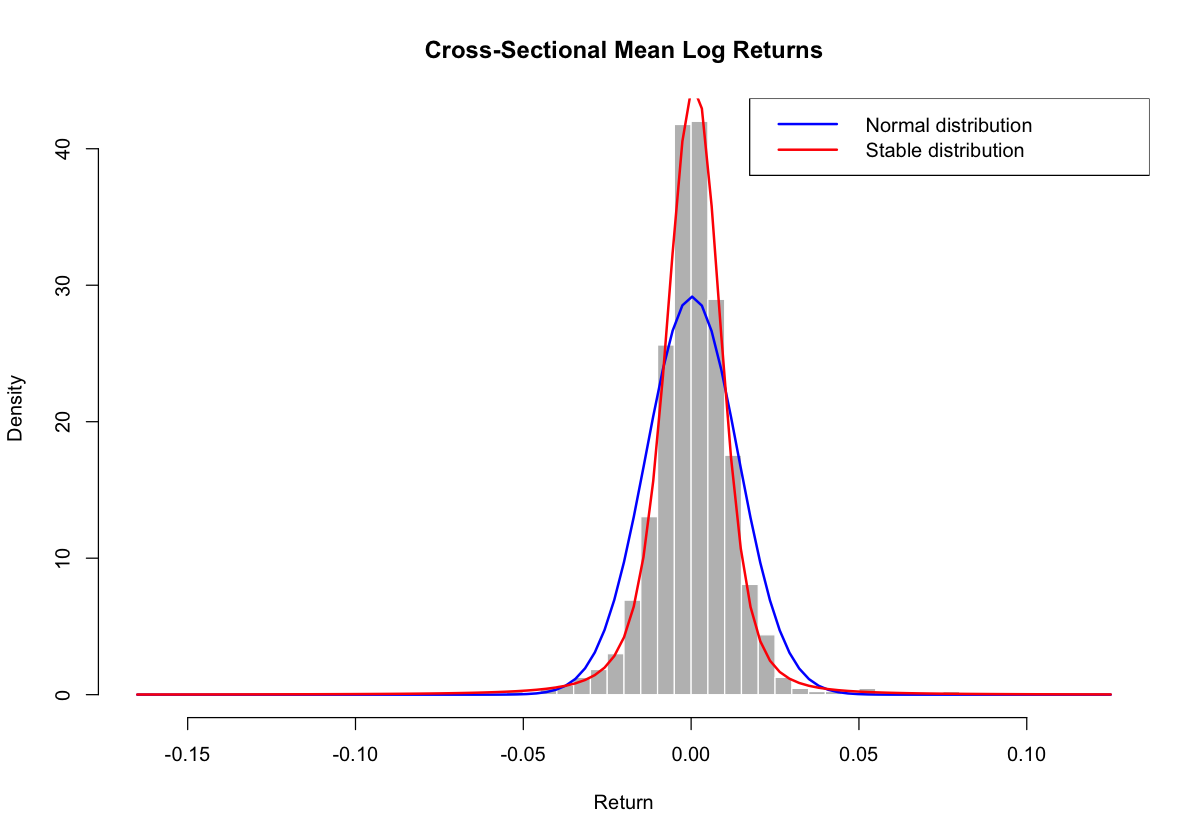

In [21]:
#Plot histogram of the mean returns and compare normal vs stable fit

options(repr.plot.width = 10, repr.plot.height = 7)

stable_parameters <- stable_mean@fit$estimate
alpha_value <- stable_parameters[1]
beta_value  <- stable_parameters[2]
gamma_value <- stable_parameters[3]
delta_value <- stable_parameters[4]

hist(mean_rets,
     breaks = 80,
     freq = FALSE,
     main = "Cross-Sectional Mean Log Returns",
     xlab = "Return",
     col = "grey",
     border = "white")

curve(dnorm(x, mean = mean(mean_rets), sd = sd(mean_rets)),
      add = TRUE, col = "blue", lwd = 2)

curve(dstable(x,
              alpha = alpha_value,
              beta = beta_value,
              gamma = gamma_value,
              delta = delta_value),
      add = TRUE, col = "red", lwd = 2)

legend("topright",
       legend = c("Normal distribution", "Stable distribution"),
       col = c("blue", "red"),
       lwd = 2)

## 4.

In [22]:
#Descriptive stats for the cross-sectional mean returns
mean_desc <- data.frame(
    mean = mean(mean_rets),
    sd = sd(mean_rets),
    min = min(mean_rets),
    max = max(mean_rets),
    skewness = skewness(mean_rets),
    kurtosis = kurtosis(mean_rets)
)

mean_desc

mean,sd,min,max,skewness,kurtosis
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.0002774959,0.01367917,-0.1633216,0.1237977,-1.15847,23.25736


In [23]:
#Recalculate descriptive statistics for each stock
stock_stats <- do.call(rbind, lapply(names(rets_list), function(ticker_name) {
  returns <- rets_list[[ticker_name]]$rets

  data.frame(
    ticker = ticker_name,
    mean = mean(returns),
    sd = sd(returns),
    min = min(returns),
    max = max(returns),
    skew = skewness(returns),
    kurt = kurtosis(returns))}
))


mean_stats <- data.frame(
  ticker = "CS_MEAN",
  mean = mean(mean_rets),
  sd = sd(mean_rets),
  min = min(mean_rets),
  max = max(mean_rets),
  skew = skewness(mean_rets),
  kurt = kurtosis(mean_rets)
)

comparison <- rbind(stock_stats, mean_stats)
format(comparison, digits = 4)

,ticker,mean,sd,min,max,skew,kurt
,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>,<I<chr>>
1,BIO,1.645e-04,0.02273,-0.1830,0.16235,-0.02129,6.936
2,CPT,2.887e-04,0.01687,-0.1971,0.10530,-0.91603,16.263
3,ELV,-1.211e-03,0.02700,-0.2571,0.13551,-3.71133,30.976
4,FE,2.780e-04,0.01716,-0.2345,0.15647,-2.66956,42.103
5,HCA,8.070e-04,0.02235,-0.2462,0.20343,-0.83526,20.541
6,MKTX,-3.970e-05,0.02238,-0.2079,0.14965,-0.82904,9.888
7,STT,5.292e-04,0.02257,-0.2098,0.20147,-0.38249,11.392
8,XOM,-9.024e-04,0.02604,-0.2687,0.11283,-4.04841,36.392
9,BSX,5.835e-04,0.01704,-0.1600,0.08849,-0.89783,8.273


In [24]:
# Set simulation values
set.seed(123)

simulations <- 500
series_l <- 1000

low_sigma <- 0.5
high_sigma <- 2.0

# Simulate random walks without drift
low_noise <- matrix(rnorm(series_l * simulations, sd = low_sigma), nrow = series_l)
high_noise <- matrix(rnorm(series_l * simulations, sd = high_sigma), nrow = series_l)

rw_low <- apply(low_noise, 2, cumsum)
rw_high <- apply(high_noise, 2, cumsum)

In [25]:
plot_random_walks <- function(random_walks, sigma_value, line_color) {

  time_index <- 1:nrow(random_walks)

  q_25 <- apply(random_walks, 1, quantile, probs = 0.25)
  q_50 <- apply(random_walks, 1, median)
  q_75 <- apply(random_walks, 1, quantile, probs = 0.75)

  upper_bound <- 2 * sigma_value * sqrt(time_index)
  lower_bound <- -2 * sigma_value * sqrt(time_index)

  plot(NULL,
       xlim = c(1, length(time_index)),
       ylim = range(random_walks),
       xlab = "Time",
       ylab = expression(X[t]),
       main = paste("Random Walk without Drift, sigma =", sigma_value))

  chosen_paths <- sample(1:ncol(random_walks), 30)
  for (j in chosen_paths) {
    lines(time_index, random_walks[, j],
          col = adjustcolor(line_color, alpha.f = 0.15), lwd = 0.5)
  }

  polygon(c(time_index, rev(time_index)),
          c(q_25, rev(q_75)),
          col = adjustcolor(line_color, alpha.f = 0.3),
          border = NA)

  lines(time_index, q_50, col = line_color, lwd = 2)
  lines(time_index, upper_bound, col = "black", lty = 2)
  lines(time_index, lower_bound, col = "black", lty = 2)

  legend("topleft",
         legend = c("Sample paths", "Middle 50%", "Median", "Theoretical bounds"),
         col = c(adjustcolor(line_color, alpha.f = 0.3),
                 adjustcolor(line_color, alpha.f = 0.3),
                 line_color,
                 "black"),
         lwd = c(1, 8, 2, 1),
         lty = c(1, 1, 1, 2),
         bty = "n")
}

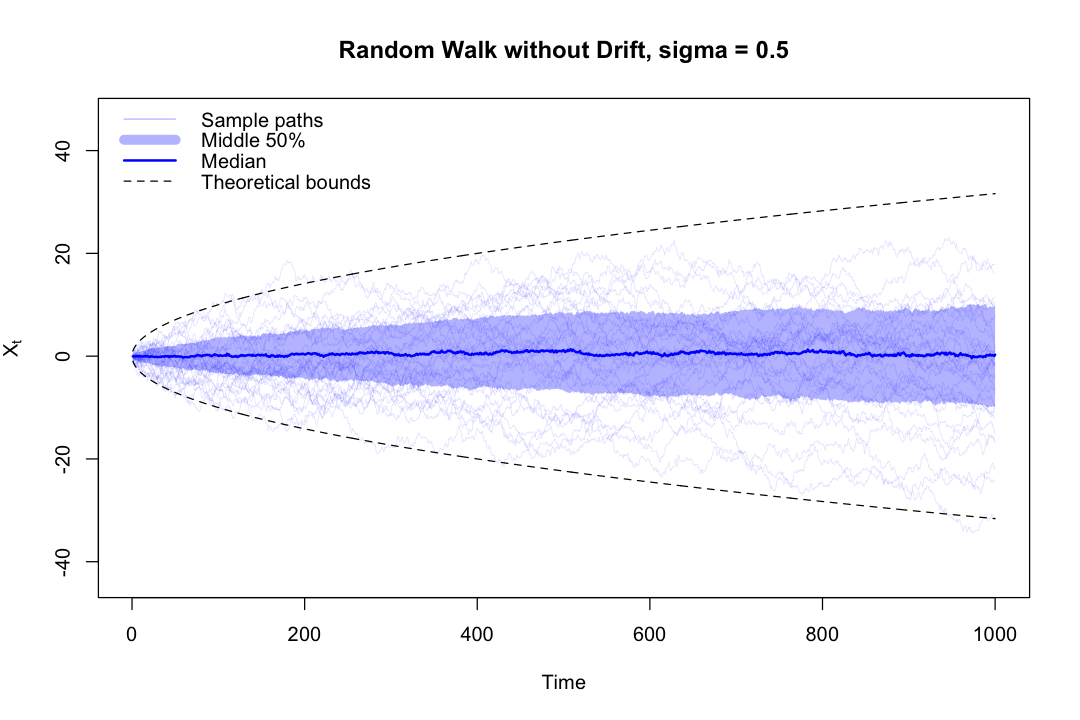

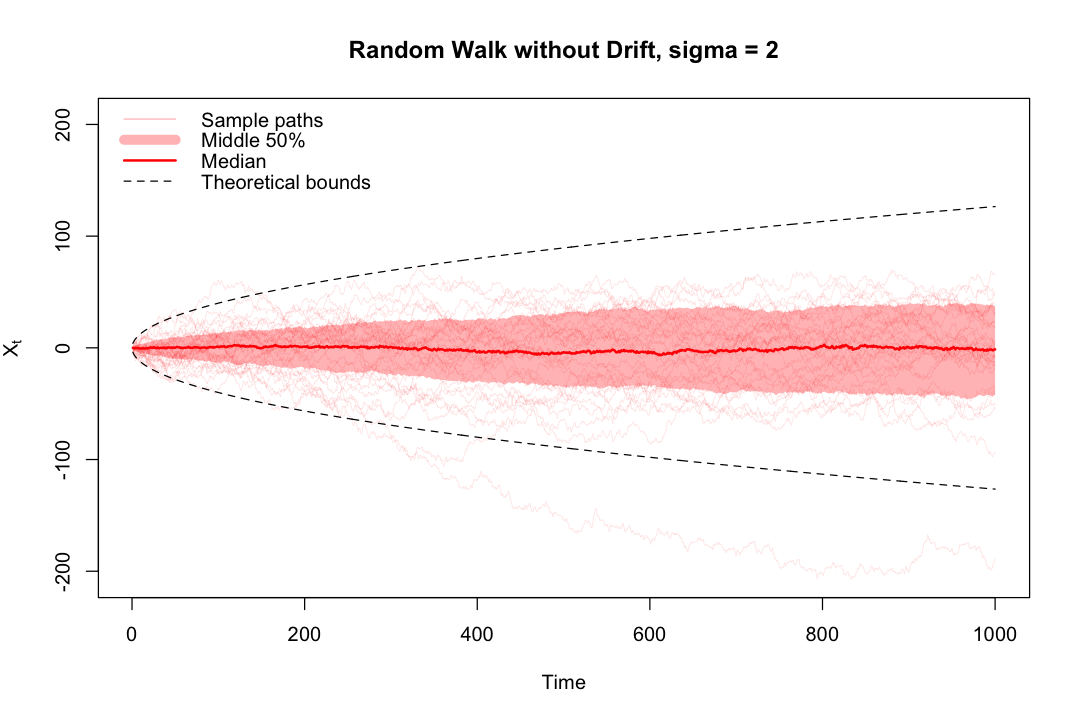

In [26]:
# Low-volatility case
options(repr.plot.width = 9, repr.plot.height = 6)
plot_random_walks(rw_low, 0.5, "blue")

# High-volatility case
plot_random_walks(rw_high, 2, "red")